## Time Series Forecasting: Cumulative GitHub Stars

In [420]:
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import itertools
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, LSTM
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random

# reproducibility
random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

def plot_username():
    plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)

### 3.1 Dataset Description

In [421]:
# contains timestamps, stars and repo ids
stars_data = pd.read_csv('./Dataset/Q3/stars_data.csv')
print(stars_data.sample(5))

print("=====")
# distribution of no of times a repo is starred
repo_star_counts = stars_data['repository_id'].value_counts()
print(repo_star_counts.head(5))

        timestamp  stars   repository_id
11316  2018-10-27   4000   pallets/flask
17252  2020-11-26   4000  torvalds/linux
1383   2017-03-12   4000  facebook/react
1114   2016-06-16   4000  facebook/react
911    2015-11-26   4000  facebook/react
=====
repository_id
pallets/flask            5691
torvalds/linux           5175
facebook/react           4542
golang/go                3991
tensorflow/tensorflow    3648
Name: count, dtype: int64


In [422]:
meta_data = pd.read_json('./Dataset/Q3/repo_metadata.json')

### 3.2 Single Repository Evaluation:

#### 3.2.1 Preprocessing and feature engineering

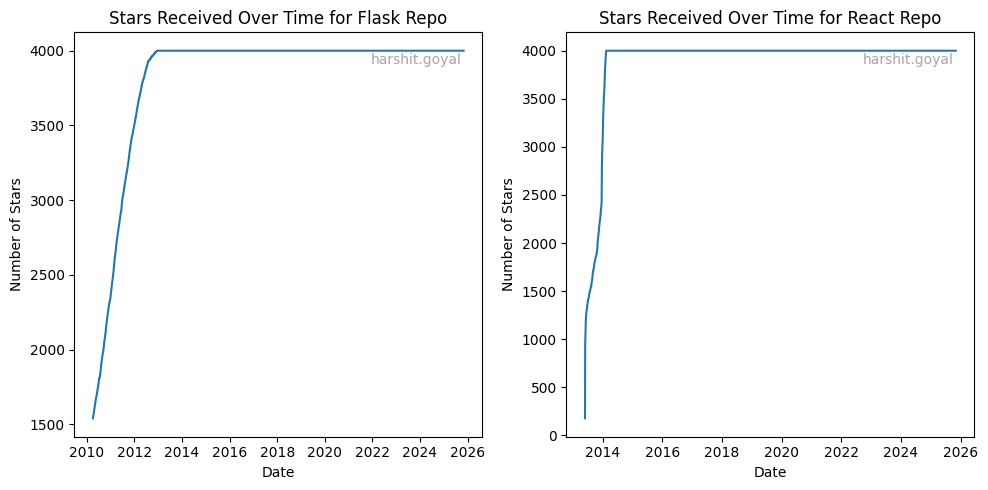

In [423]:
# chosen repo id => pallets/flask, facebook/react

flask = stars_data[stars_data['repository_id'] == 'pallets/flask']
react = stars_data[stars_data['repository_id'] == 'facebook/react']

# print(flask.shape, react.shape)

# dropping column by index
flask = flask.drop(columns=['repository_id'])
react = react.drop(columns=['repository_id'])

# count missing values
# print(flask.isnull().sum()) # no missing values
# print(react.isnull().sum()) # no missing values

flask['timestamp'] = pd.to_datetime(flask['timestamp'])
flask = flask.sort_values(by='timestamp')
flask = flask.set_index('timestamp')
# print(flask.head(10))

react['timestamp'] = pd.to_datetime(react['timestamp'])
react = react.sort_values(by='timestamp')
react = react.set_index('timestamp')
# print(react.head(10))

# check if the difference between consecutive timestamps is uniform
problem_rows = flask.iloc[1:][flask.index.to_series().diff().iloc[1:] != pd.Timedelta(days=1)]
# print(problem_rows)

problem_rows = react.iloc[1:][react.index.to_series().diff().iloc[1:] != pd.Timedelta(days=1)]
# print(problem_rows)

# no missing dates, so we can proceed to resampling
flask_daily = flask.resample('D').count()
react_daily = react.resample('D').count()

# print(flask_daily['stars'].sum() == flask.shape[0])
# print(react_daily['stars'].sum() == react.shape[0])
# this confirms that each timestamp had exactly one star event

# i choose to work in daily frequency itself

# scaling of the data
# print(react.describe())
# print(flask.describe())

# ensuring temporal integrity 
# checking if the data is monotonic increasing in time
# print(flask.index.is_monotonic_increasing)
# print(linux.index.is_monotonic_increasing)

plt.figure(figsize=(10,5))
plt.subplot(121), plt.plot(flask.index, flask['stars'])
plt.xlabel('Date'), plt.ylabel('Number of Stars')
plt.title('Stars Received Over Time for Flask Repo')
plot_username()

plt.subplot(122), plt.plot(react.index, react['stars'])
plt.xlabel('Date'), plt.ylabel('Number of Stars')
plt.title('Stars Received Over Time for React Repo')
plot_username()
plt.tight_layout()
plt.show()

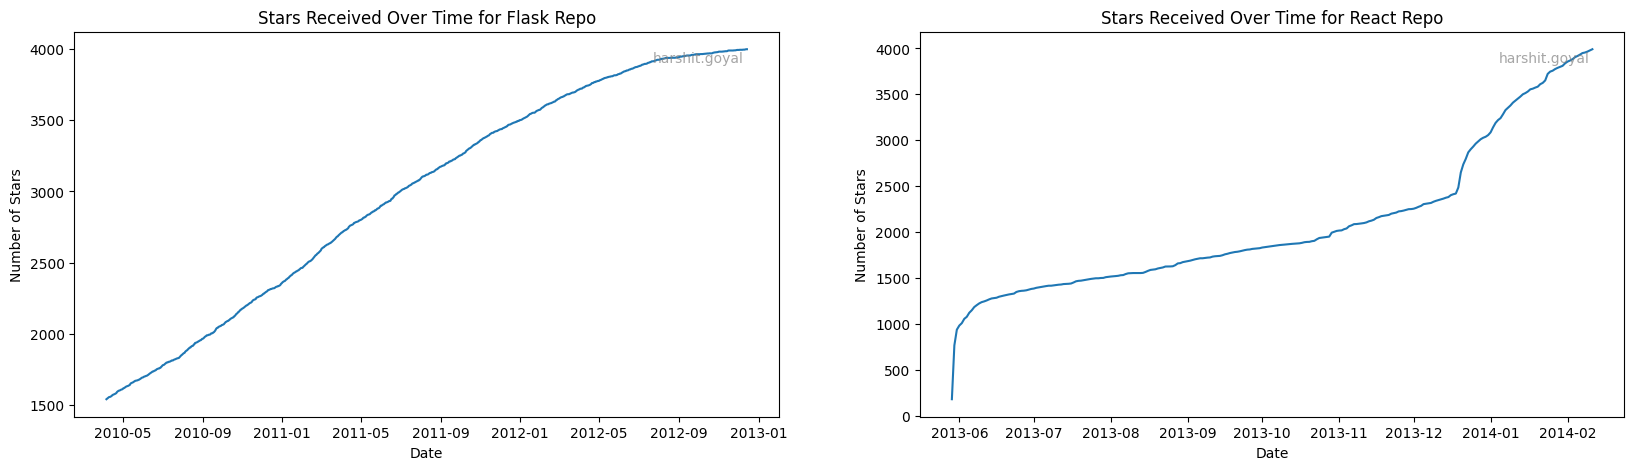

In [424]:
# i want to remove all the datapoits where stars is 4000
flask = flask[flask['stars'] < 4000]
react = react[react['stars'] < 4000]

plt.figure(figsize=(20,5))
plt.subplot(121), plt.plot(flask.index, flask['stars'])
plt.xlabel('Date'), plt.ylabel('Number of Stars')
plt.title('Stars Received Over Time for Flask Repo')
plot_username()

plt.subplot(122), plt.plot(react.index, react['stars'])
plt.xlabel('Date'), plt.ylabel('Number of Stars')
plt.title('Stars Received Over Time for React Repo')
plot_username()
plt.show()

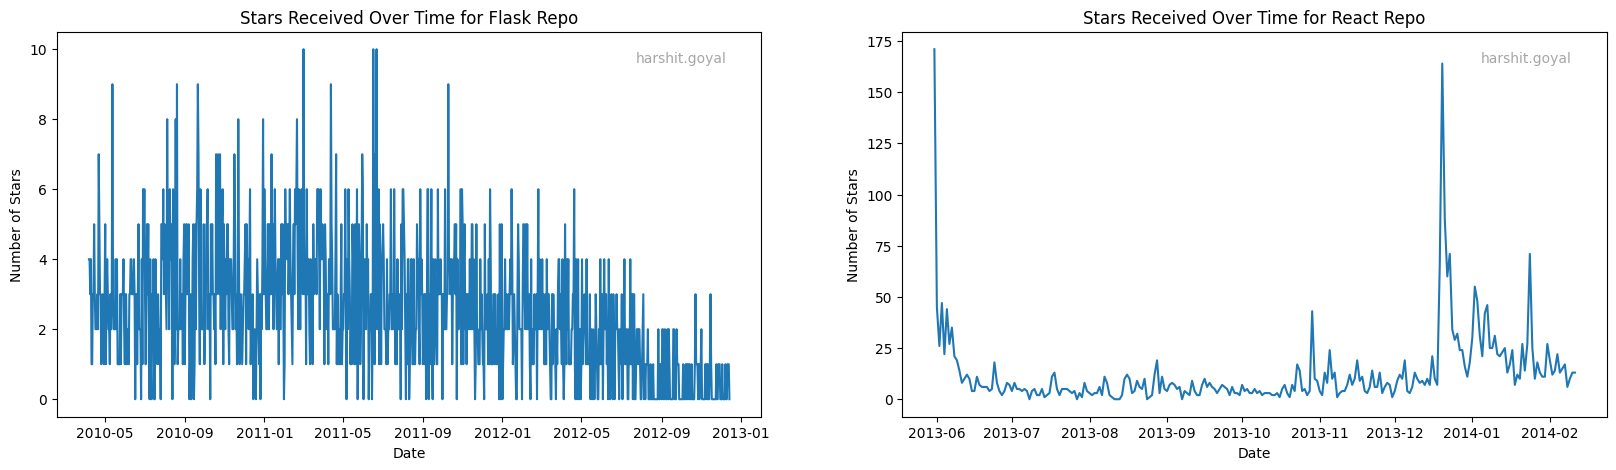

In [425]:
# the given data is cumsum, i  convert it to daily stars
flask['stars'] = flask['stars'].diff().fillna(flask['stars'].iloc[0])
react['stars'] = react['stars'].diff().fillna(react['stars'].iloc[0])

# remove first few rows
flask = flask.iloc[1:]
react = react.iloc[2:]

plt.figure(figsize=(20,5))
plt.subplot(121), plt.plot(flask.index, flask['stars'])
plt.xlabel('Date'), plt.ylabel('Number of Stars')
plt.title('Stars Received Over Time for Flask Repo')
plot_username()

plt.subplot(122), plt.plot(react.index, react['stars'])
plt.xlabel('Date'), plt.ylabel('Number of Stars')
plt.title('Stars Received Over Time for React Repo')
plot_username()
plt.show()


In [426]:
# print(flask.head())
# print(react.head())

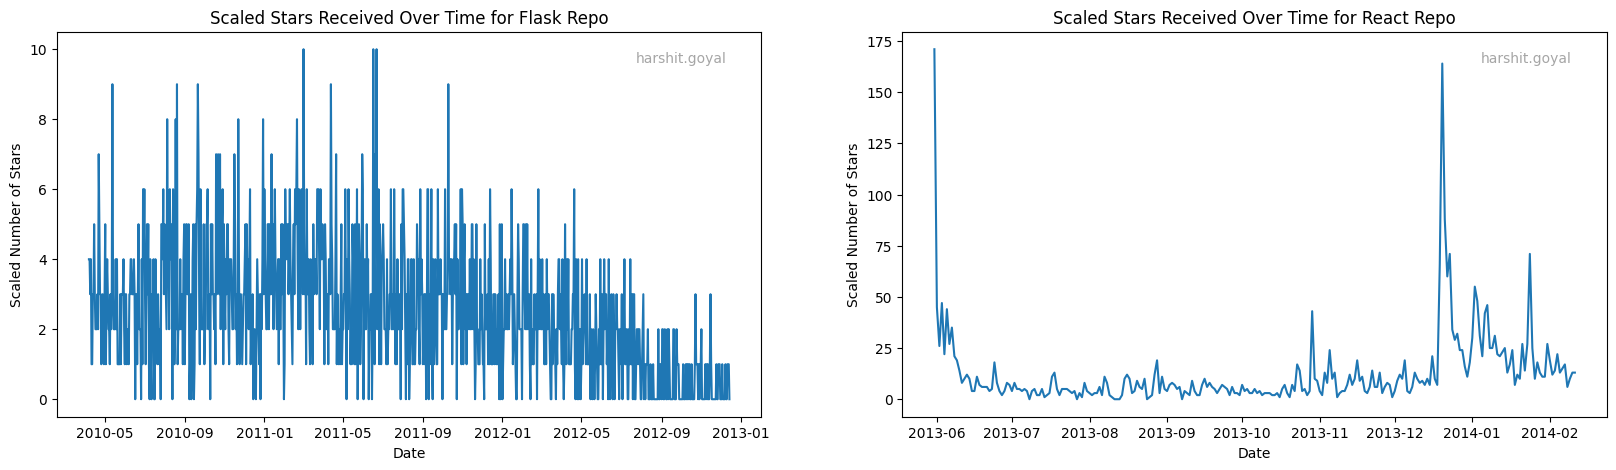

In [427]:
# print(flask.head()) # print(react.head())

plt.figure(figsize=(20,5))
plt.subplot(121), plt.plot(flask.index, flask['stars'])
plt.xlabel('Date'), plt.ylabel('Scaled Number of Stars')
plt.title('Scaled Stars Received Over Time for Flask Repo')
plot_username()

plt.subplot(122), plt.plot(react.index, react['stars'])
plt.xlabel('Date'), plt.ylabel('Scaled Number of Stars')
plt.title('Scaled Stars Received Over Time for React Repo')
plot_username()
plt.show()

### For FLASK repository

In [431]:
split_ind = int(0.8 * len(flask))
train = flask.iloc[:split_ind].squeeze()
test = flask.iloc[split_ind:].squeeze()
train = train.asfreq('D')
test = test.asfreq('D')

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))

train = pd.Series(train_scaled.flatten(), index=train.index)
test  = pd.Series(test_scaled.flatten(), index=test.index)


### ARMA Model

In [432]:
adf_result = adfuller(train.values)
print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])

# If p-value > 0.05, we treat the series as non-stationary and difference once
if adf_result[1] > 0.05:
    print("Series not stationary, applying first difference...")
    train_stationary = train.diff().dropna().squeeze()
    d_used = 1
else:
    print("Series already stationary, no differencing.")
    train_stationary = train.squeeze()
    d_used = 0

ADF statistic: -2.8477459076305185
p-value: 0.051770612453343835
Series not stationary, applying first difference...


In [433]:

# warnings.filterwarnings("ignore")

# best_aic = float("inf")
# best_order = None
# best_model = None

# p_range = range(0, 6)
# q_range = range(0, 6)

# for p, q in itertools.product(p_range, q_range):
#     if p == 0 and q == 0:
#         continue
#     try:
#         model = ARIMA(train_stationary, order=(p, 0, q))
#         fitted = model.fit()

#         # Skip non-converged models
#         if not fitted.mle_retvals.get("converged", False):
#             continue

#         # Choose the best converged model
#         if fitted.aic < best_aic:
#             best_aic = fitted.aic
#             best_order = (p, q)
#             best_model = fitted

#     except Exception:
#         continue

# print("Best *converged* ARMA(p,q):", best_order, "AIC:", best_aic)

best_order = (2, 3)
best_model = ARIMA(train_stationary, order=(2, 0, 3)).fit()

In [434]:
steps = len(test)

# Forecast on stationary scale (differenced or not)
forecast_stationary = best_model.forecast(steps=steps)

if d_used == 0:
    # No differencing → forecasts already on original scale
    forecast = forecast_stationary
else:
    # We modeled the differenced series; need to "integrate" back:
    # y_t = y_{last_train} + cumulative sum of predicted differences
    last_train_value = train.iloc[-1]
    forecast = last_train_value + forecast_stationary.cumsum()

# Align index with test
forecast.index = test.index


### Deep Learning Model RNN forecaster`

In [435]:

def create_sequences(data, window=60):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 60

X_train, y_train = create_sequences(train.values, window)
X_test,  y_test  = create_sequences(test.values,  window)

# RNN expects shape: (samples, timesteps, features)
X_train = X_train.reshape(-1, window, 1)
X_test  = X_test.reshape(-1, window, 1)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)


Train shape: (726, 60, 1) (726,)
Test shape : (137, 60, 1) (137,)


In [436]:
tf.keras.backend.clear_session()
model_rnn = Sequential([
    LSTM(32, return_sequences=False, input_shape=(window, 1)),
    Dense(16, activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [437]:
history = model_rnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0997 - val_loss: 0.0235
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0411 - val_loss: 0.0200
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0361 - val_loss: 0.0247
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0335 - val_loss: 0.0224
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0340 - val_loss: 0.0231
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0338 - val_loss: 0.0227
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0338 - val_loss: 0.0226
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0339 - val_loss: 0.0227
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0339 - val_loss: 0.0226
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0339 - val_loss: 0.0226
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0339 - val_loss: 0.0225
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0339 -

### 1-D CNN forecaster

In [438]:
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 60

X_train, y_train = create_sequences(train.values, window)
X_test,  y_test  = create_sequences(test.values,  window)

# CNN also requires 3D shape: (samples, timesteps, channels)
X_train = X_train.reshape(-1, window, 1)
X_test  = X_test.reshape(-1, window, 1)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (726, 60, 1) (726,)
Test : (137, 60, 1) (137,)


In [439]:
tf.keras.backend.clear_session()
model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(window, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=16, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')
model_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 432)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,569 (60.82 KB)

 Trainable params: 15,569 (60.82 KB)

 Non-trainable params: 0 (0.00 B)

In [440]:
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0508 - val_loss: 0.0200
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0375 - val_loss: 0.0190
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0353 - val_loss: 0.0199
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0339 - val_loss: 0.0196
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0337 - val_loss: 0.0193
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0335 - val_loss: 0.0191
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0338 - val_loss: 0.0190
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0340 - val_loss: 0.0192
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0336 - val_loss: 0.0193
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0335 - val_loss: 0.0196
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0329 - val_loss: 0.0197
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0324 - val_l

In [441]:
window = 60

def create_sequences(data, window=60):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train.values, window)
X_test,  y_test  = create_sequences(test.values, window)

# reshape for neural networks
X_train = X_train.reshape(-1, window, 1)
X_test  = X_test.reshape(-1, window, 1)

In [442]:
def evaluate_single_step(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [443]:
# RNN
rnn_pred_1 = model_rnn.predict(X_test).flatten()
rnn_mae_1, rnn_rmse_1 = evaluate_single_step(y_test, rnn_pred_1)

# CNN
cnn_pred_1 = model_cnn.predict(X_test).flatten()
cnn_mae_1, cnn_rmse_1 = evaluate_single_step(y_test, cnn_pred_1)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [444]:
arma_pred_1 = forecast.values[:len(y_test)]
arma_mae_1, arma_rmse_1 = evaluate_single_step(y_test, arma_pred_1)

In [445]:
print("====== SINGLE-STEP (h=1) ======")
print(f"ARMA → MAE={arma_mae_1:.4f}, RMSE={arma_rmse_1:.4f}")
print(f"RNN  → MAE={rnn_mae_1:.4f}, RMSE={rnn_rmse_1:.4f}")
print(f"CNN  → MAE={cnn_mae_1:.4f}, RMSE={cnn_rmse_1:.4f}")


====== SINGLE-STEP (h=1) ======
ARMA → MAE=0.1191, RMSE=0.1302
RNN  → MAE=0.1319, RMSE=0.1441
CNN  → MAE=0.1096, RMSE=0.1254


In [446]:
def multi_step_forecast(model, last_window, horizon):
    """
    last_window: last 60 days (shape: (60,))
    horizon: number of future steps to predict
    """
    preds = []
    window = list(last_window)

    for _ in range(horizon):
        x_input = np.array(window[-60:]).reshape(1, 60, 1)
        next_val = model.predict(x_input)[0][0]
        preds.append(next_val)
        window.append(next_val)

    return np.array(preds)


In [447]:
horizons = [1, 3, 7, 14, 30]
true_test_values = test.values   # 1D array

In [448]:
def arma_multi_step(best_model, train, test, horizon):
    future = best_model.forecast(steps=horizon)
    if d_used == 1:
        last_val = train.iloc[-1]
        future = last_val + future.cumsum()
    return future.values

In [449]:
mae_arma_list = []
rmse_arma_list = []
mae_rnn_list  = []
rmse_rnn_list = []
mae_cnn_list  = []
rmse_cnn_list = []


for h in horizons:
    # ARMA
    arma_h = arma_multi_step(best_model, train, test, h)
    arma_mae, arma_rmse = evaluate_single_step(true_test_values[:h], arma_h)
    mae_arma_list.append(arma_mae)
    rmse_arma_list.append(arma_rmse)

    # RNN
    rnn_h = multi_step_forecast(model_rnn, true_test_values[:window], h)
    rnn_mae, rnn_rmse = evaluate_single_step(true_test_values[:h], rnn_h)
    mae_rnn_list.append(rnn_mae)
    rmse_rnn_list.append(rnn_rmse)

    # CNN
    cnn_h = multi_step_forecast(model_cnn, true_test_values[:window], h)
    cnn_mae, cnn_rmse = evaluate_single_step(true_test_values[:h], cnn_h)
    mae_cnn_list.append(cnn_mae)
    rmse_cnn_list.append(cnn_rmse)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

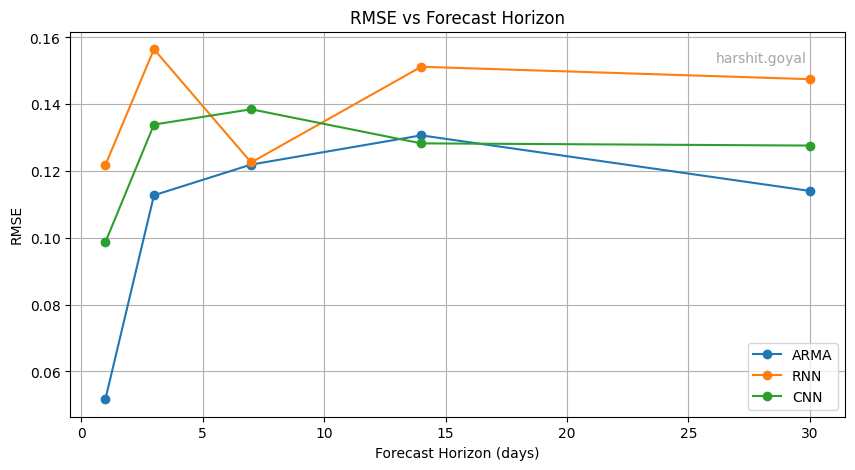

In [450]:
plt.figure(figsize=(10,5))
plt.plot(horizons, rmse_arma_list, marker='o', label='ARMA')
plt.plot(horizons, rmse_rnn_list, marker='o', label='RNN')
plt.plot(horizons, rmse_cnn_list, marker='o', label='CNN')
plt.xlabel("Forecast Horizon (days)")
plt.ylabel("RMSE")
plt.title("RMSE vs Forecast Horizon")
plot_username()
plt.legend(), plt.grid(True)
plt.show()

### For React repository

In [451]:
split_ind = int(0.8 * len(react))
train = react.iloc[:split_ind].squeeze()
test = react.iloc[split_ind:].squeeze()
train = train.asfreq('D')
test = test.asfreq('D')

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))
train = pd.Series(train_scaled.flatten(), index=train.index)
test  = pd.Series(test_scaled.flatten(), index=test.index)

### ARMA Model

In [452]:
adf_result = adfuller(train.values)
print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])

# If p-value > 0.05, we treat the series as non-stationary and difference once
if adf_result[1] > 0.05:
    print("Series not stationary, applying first difference...")
    train_stationary = train.diff().dropna().squeeze()
    d_used = 1
else:
    print("Series already stationary, no differencing.")
    train_stationary = train.squeeze()
    d_used = 0

ADF statistic: -2.6331749648137364
p-value: 0.08633266716506682
Series not stationary, applying first difference...


In [453]:

# warnings.filterwarnings("ignore")

# best_aic = float("inf")
# best_order = None
# best_model = None

# p_range = range(0, 6)
# q_range = range(0, 6)

# for p, q in itertools.product(p_range, q_range):
#     if p == 0 and q == 0:
#         continue
#     try:
#         model = ARIMA(train_stationary, order=(p, 0, q))
#         fitted = model.fit()

#         # Skip non-converged models
#         if not fitted.mle_retvals.get("converged", False):
#             continue

#         # Choose the best converged model
#         if fitted.aic < best_aic:
#             best_aic = fitted.aic
#             best_order = (p, q)
#             best_model = fitted

#     except Exception:
#         continue

# print("Best *converged* ARMA(p,q):", best_order, "AIC:", best_aic)

best_order = (1, 2)
best_model = ARIMA(train_stationary, order=(1, 0, 2)).fit()

In [454]:
steps = len(test)

# Forecast on stationary scale (differenced or not)
forecast_stationary = best_model.forecast(steps=steps)

if d_used == 0:
    # No differencing → forecasts already on original scale
    forecast = forecast_stationary
else:
    # We modeled the differenced series; need to "integrate" back:
    # y_t = y_{last_train} + cumulative sum of predicted differences
    last_train_value = train.iloc[-1]
    forecast = last_train_value + forecast_stationary.cumsum()

# Align index with test
forecast.index = test.index


### Deep Learning Model RNN forecaster`

In [455]:

def create_sequences(data, window=60):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 30

X_train, y_train = create_sequences(train.values, window)
X_test,  y_test  = create_sequences(test.values,  window)

# RNN expects shape: (samples, timesteps, features)
X_train = X_train.reshape(-1, window, 1)
X_test  = X_test.reshape(-1, window, 1)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)


Train shape: (175, 30, 1) (175,)
Test shape : (22, 30, 1) (22,)


In [456]:
tf.keras.backend.clear_session()
model_rnn = Sequential([
    LSTM(32, return_sequences=False, input_shape=(window, 1)),
    Dense(16, activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [457]:
history = model_rnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 9.1197e-04 - val_loss: 0.0592
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9.6076e-04 - val_loss: 0.0639
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 8.5869e-04 - val_loss: 0.0620
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.2456e-04 - val_loss: 0.0603
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.6121e-04 - val_loss: 0.0618
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.3927e-04 - val_loss: 0.0615
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.1758e-04 - val_loss: 0.0603
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.3678e-04 - val_loss: 0.0605
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.3343e-04 - val_loss: 0.0606
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.2182e-04 - val_loss: 0.0599
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.2807e-04 - val_loss: 0.0598
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1

### 1-D CNN forecaster

In [458]:
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 30

X_train, y_train = create_sequences(train.values, window)
X_test,  y_test  = create_sequences(test.values,  window)

# CNN also requires 3D shape: (samples, timesteps, channels)
X_train = X_train.reshape(-1, window, 1)
X_test  = X_test.reshape(-1, window, 1)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (175, 30, 1) (175,)
Test : (22, 30, 1) (22,)


In [459]:
tf.keras.backend.clear_session()
model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(window, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=16, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')
model_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,889 (30.82 KB)

 Trainable params: 7,889 (30.82 KB)

 Non-trainable params: 0 (0.00 B)

In [460]:
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0011 - val_loss: 0.0652
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0010 - val_loss: 0.0676
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.5283e-04 - val_loss: 0.0688
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.0104e-04 - val_loss: 0.0671
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.6927e-04 - val_loss: 0.0659
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.8158e-04 - val_loss: 0.0665
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.5756e-04 - val_loss: 0.0671
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.2481e-04 - val_loss: 0.0670
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.1357e-04 - val_loss: 0.0671
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.9994e-04 - val_loss: 0.0677
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.7727e-04 - val_loss: 0.0675
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

In [461]:
window = 30

def create_sequences(data, window=60):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train.values, window)
X_test,  y_test  = create_sequences(test.values, window)

# reshape for neural networks
X_train = X_train.reshape(-1, window, 1)
X_test  = X_test.reshape(-1, window, 1)

In [462]:
# RNN
rnn_pred_1 = model_rnn.predict(X_test).flatten()
rnn_mae_1, rnn_rmse_1 = evaluate_single_step(y_test, rnn_pred_1)

# CNN
cnn_pred_1 = model_cnn.predict(X_test).flatten()
cnn_mae_1, cnn_rmse_1 = evaluate_single_step(y_test, cnn_pred_1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [463]:
arma_pred_1 = forecast.values[:len(y_test)]
arma_mae_1, arma_rmse_1 = evaluate_single_step(y_test, arma_pred_1)

In [464]:
print("====== SINGLE-STEP (h=1) ======")
print(f"ARMA → MAE={arma_mae_1:.4f}, RMSE={arma_rmse_1:.4f}")
print(f"RNN  → MAE={rnn_mae_1:.4f}, RMSE={rnn_rmse_1:.4f}")
print(f"CNN  → MAE={cnn_mae_1:.4f}, RMSE={cnn_rmse_1:.4f}")


====== SINGLE-STEP (h=1) ======
ARMA → MAE=0.3701, RMSE=0.3788
RNN  → MAE=0.0433, RMSE=0.0811
CNN  → MAE=0.0650, RMSE=0.1041


In [465]:
def multi_step_forecast(model, last_window, horizon):
    """
    last_window: last 60 days (shape: (60,))
    horizon: number of future steps to predict
    """
    preds = []
    window = list(last_window)

    for _ in range(horizon):
        x_input = np.array(window[-30:]).reshape(1, 30, 1)
        next_val = model.predict(x_input)[0][0]
        preds.append(next_val)
        window.append(next_val)

    return np.array(preds)


In [466]:
horizons = [1, 3, 7, 14, 30]
true_test_values = test.values   # 1D array

In [467]:
mae_arma_list = []
rmse_arma_list = []
mae_rnn_list  = []
rmse_rnn_list = []
mae_cnn_list  = []
rmse_cnn_list = []


for h in horizons:
    # ARMA
    arma_h = arma_multi_step(best_model, train, test, h)
    arma_mae, arma_rmse = evaluate_single_step(true_test_values[:h], arma_h)
    mae_arma_list.append(arma_mae)
    rmse_arma_list.append(arma_rmse)

    # RNN
    rnn_h = multi_step_forecast(model_rnn, true_test_values[:window], h)
    rnn_mae, rnn_rmse = evaluate_single_step(true_test_values[:h], rnn_h)
    mae_rnn_list.append(rnn_mae)
    rmse_rnn_list.append(rnn_rmse)

    # CNN
    cnn_h = multi_step_forecast(model_cnn, true_test_values[:window], h)
    cnn_mae, cnn_rmse = evaluate_single_step(true_test_values[:h], cnn_h)
    mae_cnn_list.append(cnn_mae)
    rmse_cnn_list.append(cnn_rmse)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━

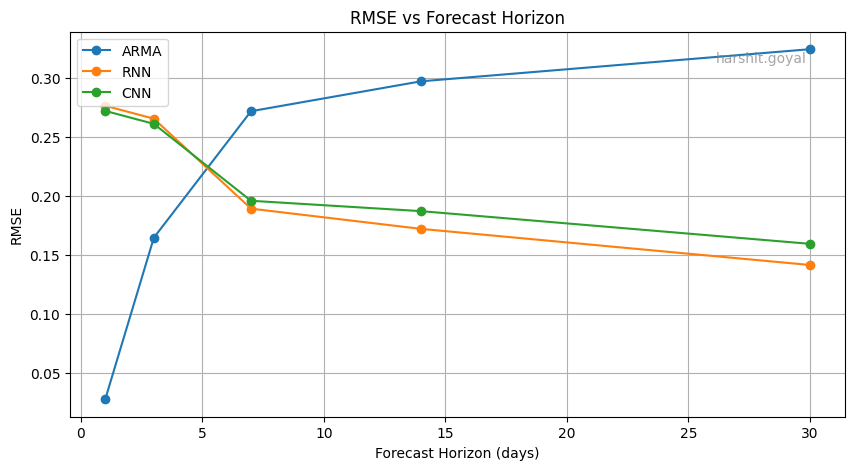

In [468]:
plt.figure(figsize=(10,5))
plt.plot(horizons, rmse_arma_list, marker='o', label='ARMA')
plt.plot(horizons, rmse_rnn_list, marker='o', label='RNN')
plt.plot(horizons, rmse_cnn_list, marker='o', label='CNN')
plt.xlabel("Forecast Horizon (days)")
plt.ylabel("RMSE")
plt.title("RMSE vs Forecast Horizon")
plot_username()
plt.legend(), plt.grid(True)
plt.show()